In [3]:
# Market basket Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('../data/online_retail_raw.csv', parse_dates=['InvoiceDate'])

df_clean = df[
    df['CustomerID'].notna() &
    ~df['InvoiceNo'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Data loaded:", df_clean.shape) 
df_clean.head()

Data loaded: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [4]:
!pip install mlxtend --user

In [6]:
from mlxtend.frequent_patterns import apriori, association_rules

# Build basket matrix: rows = invoices, columns = products, values = 1/0
basket = df_clean[df_clean['Country'] == 'United Kingdom'].groupby(
    ['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Convert to binary (bought or not)
basket_binary = basket.map(lambda x: 1 if x > 0 else 0)

print("Basket matrix shape:", basket_binary.shape)
basket_binary.head()

Basket matrix shape: (16646, 3844)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Apply Apriori - minimum support 2%
frequent_itemsets = apriori(basket_binary, min_support=0.02, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.head(10))

C:\Users\camgu\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent itemsets found: 235
      support                                         itemsets
184  0.113180  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
79   0.086928             frozenset({JUMBO BAG RED RETROSPOT})
149  0.084705            frozenset({REGENCY CAKESTAND 3 TIER})
11   0.078097       frozenset({ASSORTED COLOUR BIRD ORNAMENT})
123  0.077496                       frozenset({PARTY BUNTING})
101  0.067283             frozenset({LUNCH BAG RED RETROSPOT})
159  0.060495   frozenset({SET OF 3 CAKE TINS PANTRY DESIGN })
94   0.059834             frozenset({LUNCH BAG  BLACK SKULL.})
119  0.056770     frozenset({PAPER CHAIN KIT 50'S CHRISTMAS })
108  0.056350     frozenset({NATURAL SLATE HEART CHALKBOARD })


In [8]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.5)
rules = rules.sort_values('lift', ascending=False)

print(f"Rules found: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Rules found: 76
                                          antecedents  \
67       frozenset({GREEN REGENCY TEACUP AND SAUCER})   
66  frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...   
68        frozenset({PINK REGENCY TEACUP AND SAUCER})   
65  frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...   
28       frozenset({GREEN REGENCY TEACUP AND SAUCER})   
29        frozenset({PINK REGENCY TEACUP AND SAUCER})   
64  frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...   
69      frozenset({ROSES REGENCY TEACUP AND SAUCER })   
5       frozenset({ROSES REGENCY TEACUP AND SAUCER })   
4        frozenset({GREEN REGENCY TEACUP AND SAUCER})   

                                          consequents   support  confidence  \
67  frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...  0.020485    0.557190   
66       frozenset({GREEN REGENCY TEACUP AND SAUCER})  0.020485    0.890339   
68  frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...  0.020485    0.691684   
65        frozenset({PINK REGENCY TEACUP

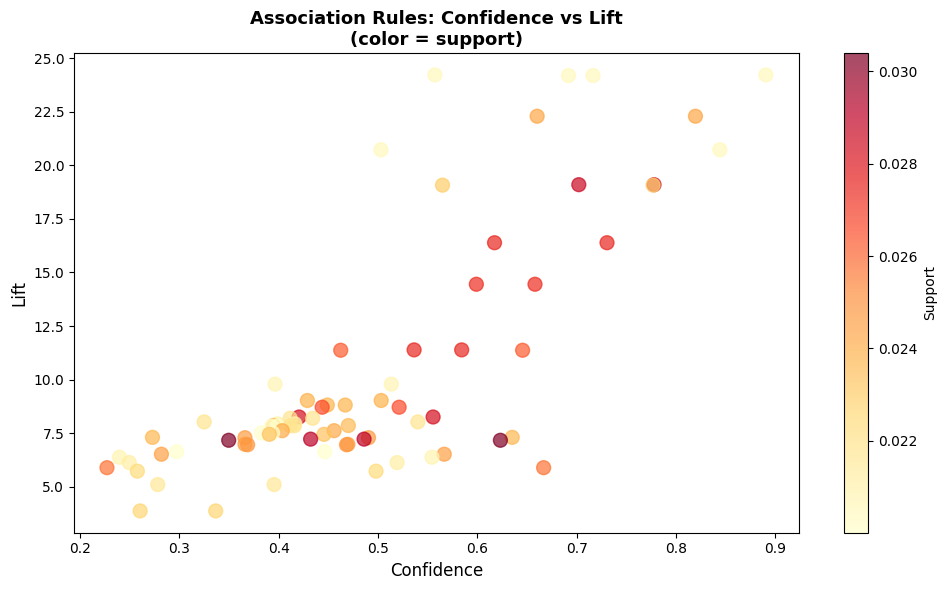

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    rules['confidence'], 
    rules['lift'],
    c=rules['support'], 
    cmap='YlOrRd',
    s=100,
    alpha=0.7
)

plt.colorbar(scatter, label='Support')
ax.set_xlabel('Confidence', fontsize=12)
ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Association Rules: Confidence vs Lift\n(color = support)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/market_basket_rules.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- **The Regency Teacup collection (Green, Pink, Roses) shows the strongest 
associations in the dataset**, with lift values of 24x and confidence between 
55–89%, meaning customers consistently purchase them together as a set.

- **Recommendation:** Bundle the three Regency Teacup variants as a collection 
pack, or implement product recommendations ("customers also bought") when any 
one of the three is added to the cart.

- **76 association rules were found** with lift > 1.5, indicating multiple 
cross-sell opportunities beyond the Teacup collection across UK customers.

- The Apriori algorithm was applied with a minimum support of 2%, ensuring 
rules are based on sufficiently frequent purchase patterns to be actionable.